# Wind Stress Magnitude, Direction and Curl

Related issue: https://github.com/ACCESS-Community-Hub/access-om3-paper-1/issues/12

In [1]:
# These first two cells must be in all notebooks!
# It allows us to run all the notebooks at once, this cell has a tag "parameters" which allows us to pass in 
# arguments externally using papermill (see mkfigs.sh for details)

# Set esm_file to the datastore for the main experiment of interest
# esm_file = "/g/data/ol01/outputs/access-om3-25km/25km-iaf-test-for-AK-expt-7df5ef4c/datastore.json"
# esm_file = "/g/data/ol01/outputs/access-om3-25km/MC_25km_jra_iaf-1.0-beta-5165c0f8/datastore.json"
esm_file = "/g/data/ol01/outputs/access-om3-25km/MC_25km_jra_iaf+wombatlite-test3v2-00532b88/datastore.json"

# papermill settings. *No need to modify these if running interactively.* 
papermill = False                      # `cwd` and `nbname` will be populated by papermill.
cwd = None                             # current working directory 
nbname = None                          # notebook name

In [2]:
if not papermill: 
    import nci_ipynb, os  # requires conda/analysis3-26.03 or later
    cwd = nci_ipynb.dir()
    nbname = nci_ipynb.name()
    os.chdir(cwd)
import mkfigs_bootstrap  # noqa: adds external/access-model-mkfigs/src to sys.path (stop-gap)
from mkfigs import MkmdWriter
mkmd = MkmdWriter(esm_file, nbname, str(cwd), pm=papermill)

In [3]:
import xarray as xr
import intake
import cartopy.crs as ccrs
import matplotlib.pyplot as plt
from distributed import Client
import cftime
import os
import matplotlib.pyplot as plt
import cmocean as cm
import numpy as np
import xgcm

In [4]:
client = Client(threads_per_worker=1)
client

Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: /proxy/8787/status,
Dashboard: /proxy/8787/status,Workers: 14
Total threads: 14,Total memory: 63.00 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:38801,Workers: 0
Dashboard: /proxy/8787/status,Total threads: 0
Started: Just now,Total memory: 0 B
Comm: tcp://127.0.0.1:38243,Total threads: 1
Dashboard: /proxy/45231/status,Memory: 4.50 GiB
Nanny: tcp://127.0.0.1:41431,


In [5]:
IAF = esm_file.find('iaf') > 0
IAF

True

### Define data sources

In [6]:
exptname = os.path.basename(os.path.dirname(esm_file))

In [7]:
catalogs = [
                # '/g/data/ol01/access-om3-output/access-om3-025/25km-iaf-test-for-AK-expt-7df5ef4c/datastore.json',
                # '/g/data/ol01/access-om3-output/access-om3-025/MC_25km_jra_ryf-1.0-beta/experiment_datastore.json',
                esm_file,
                '/g/data/ol01/outputs/access-om3-25km/MC_25km_jra_iaf+wombatlite-test3v2-COARE-12fab415/datastore.json',
            ]
catalogs

['/g/data/ol01/outputs/access-om3-25km/MC_25km_jra_iaf+wombatlite-test3v2-00532b88/datastore.json',
 '/g/data/ol01/outputs/access-om3-25km/MC_25km_jra_iaf+wombatlite-test3v2-COARE-12fab415/datastore.json']

In [8]:
datastores = { os.path.normpath(c).split(os.sep)[-2]:
               intake.open_esm_datastore(c, columns_with_iterables=['variable'])
              for c in catalogs }
datastores

{'MC_25km_jra_iaf+wombatlite-test3v2-00532b88': <datastore catalog with 24 dataset(s) from 32927 asset(s)>,
 'MC_25km_jra_iaf+wombatlite-test3v2-COARE-12fab415': <datastore catalog with 24 dataset(s) from 16791 asset(s)>}

In [9]:
# ACCESS-OM2-025 experiment
# use control - see https://forum.access-hive.org.au/t/access-om2-control-experiments/258
if IAF:
    om2expt = '025deg_jra55_iaf_omip2_cycle1'
else:
    om2expt = '025deg_jra55_ryf9091_gadi'
om2cat = intake.cat.access_nri[om2expt]

/g/data/xp65/public/apps/med_conda/envs/analysis3-26.03/lib/python3.12/site-packages/intake/catalog/utils.py:173: UserWarning: Shell command not executed due to getshell=False
  warnings.warn("Shell command not executed due to getshell=False")
/g/data/xp65/public/apps/med_conda/envs/analysis3-26.03/lib/python3.12/site-packages/intake/catalog/utils.py:182: UserWarning: Shell command not executed due to getshell=False
  warnings.warn("Shell command not executed due to getshell=False")


### Load OM3 grid data

In [10]:
static = xr.open_dataset(datastores[exptname].search(filename="access-om3.mom6.static.nc").df.loc[0, "path"]).drop_vars("time")

In [11]:
# See https://xgcm.readthedocs.io/en/latest/xgcm-examples/03_MOM6/#xgcm-grid-definition
symmetric = True  # True for ACCESS-OM3 2025.08.000 and later

if symmetric:  # ACCESS-OM3 version 2025.08.000 and later: one more q point than h points
    coords={
        'X': {'center': 'xh', 'outer': 'xq'},
        'Y': {'center': 'yh', 'outer': 'yq'},
    }
else:  # ACCESS-OM3 versions prior to 2025.08.000: equal number of q and h points
    coords={
        'X': {'center': 'xh', 'right': 'xq'},
        'Y': {'center': 'yh', 'right': 'yq'},
    }

grid = xgcm.Grid(
    static,
    coords=coords,
    metrics = {
        ('X',): ['dxt', 'dxCu', 'dxCv'], # X distances
        ('Y',): ['dyt', 'dyCu', 'dyCv'], # Y distances
        ('X', 'Y'): ['areacello', 'areacello_cu', 'areacello_cv', 'areacello_bu'] # Areas
    },
    periodic=['X'],
    autoparse_metadata=False
# Note, autoparse_metadata=False is required below for xgcm >= 0.9.0 to prevent xgcm 
# from trying to autoparse non-existent grid information from the file metadata, 
# leading to the error:
# ValueError: Found two coordinates without `c_grid_axis_shift` attribute for axis X
)

### Load ACCESS-OM3-25km and ACCESS-OM2-025 wind stress diagnostics 

In [12]:
fields = { # key is OM3 name, value is OM2 name
    'tauuo': 'tau_x',
    'tauvo': 'tau_y',
}
fields

{'tauuo': 'tau_x', 'tauvo': 'tau_y'}

In [13]:
# from https://github.com/COSIMA/cosima-recipes/blob/main/Cooking-Lessons-101-Tutorials/ACCESS-NRI_Intake_Catalog.ipynb
# Speeding up opening your datasets
# Try passing the following argument to your to_dask or to_dataset_dict call:
# See the xarray documentation on Reading multi-file datasets for more details about these arguments.
# https://docs.xarray.dev/en/stable/user-guide/io.html#reading-multi-file-datasets

xarray_combine_by_coords_kwargs=dict(
    compat="override",
    data_vars="minimal",
    coords="minimal"
)

In [14]:
# load data
data = dict()
for k, om2 in fields.items():
    print(k)
    try:
        d = { n: ds.search(variable=k, frequency='1mon', variable_cell_methods='.*time: mean.*') for n, ds in datastores.items() }
        d = { n: ds.to_dask(xarray_combine_by_coords_kwargs=xarray_combine_by_coords_kwargs,
                            xarray_open_kwargs = dict(chunks={"time": -1}, decode_timedelta=True)
                           ) for n, ds in d.items() if ds } # avoid .to_dask() for empty datasets
    except:
        print(f'{k} failed')
        continue
    if om2 is None: # add access-om2 data,with variable name changed to match om3
        d2 = {}
    else:
        d2 = {om2expt: om2cat.search(variable=om2, 
                                     frequency=d[list(d.keys())[0]].attrs['intake_esm_attrs:frequency']
                                    ).to_dask().rename({om2: k})}
    data[k] = d2 | d

if IAF:
    for vname, d in data.items():
        for expt in d.keys():
            try:
                d[expt] = d[expt].convert_calendar("proleptic_gregorian", use_cftime=True)
            except KeyError:
                pass

tauuo
tauvo


### Trim to a consistent time range

In [15]:
# find largest overlapping time range

# latest start date in data
datastart = np.max([ data['tauuo'][e].time.values[0] for e in data['tauuo'].keys() ])

# earliest end date in data
datastop = np.min([ data['tauuo'][e].time.values[-1] for e in data['tauuo'].keys() ])

print ('common data range:', datastart, ' to ', datastop)

# bracket to start/end of year
datestart = cftime.datetime(cftime.to_tuple(datastart)[0],  1, 1, calendar=datastop.calendar)
datestop  = cftime.datetime(cftime.to_tuple(datastop)[0], 12, 31, 23, 59, 59, calendar=datastop.calendar)

timeslice = slice(datestart, datestop)
timeslice

common data range: 1990-01-16 12:00:00  to  2018-12-14 12:00:00


slice(cftime.datetime(1990, 1, 1, 0, 0, 0, 0, calendar='proleptic_gregorian', has_year_zero=True), cftime.datetime(2018, 12, 31, 23, 59, 59, 0, calendar='proleptic_gregorian', has_year_zero=True), None)

In [16]:
# trim everything to timeslice
data = { vname: {expt: da.sel(time=timeslice) for expt, da in dct.items()} for vname, dct in data.items() }

### Time-means

In [17]:
def mean_of_monthly_means(da):
    """Correctly-weighted time-mean of monthly mean data"""
    days_in_month = da.time.dt.days_in_month
    return (da * days_in_month).sum("time") / days_in_month.sum("time")

In [18]:
%%time
# new dict containing time-mean dataarrays
data_tm = dict()
for vname, d in data.items():
    data_tm[vname] = dict()
    for expt, ds in d.items():
        data_tm[vname][expt] = mean_of_monthly_means(ds[vname]).load()

CPU times: user 22.3 s, sys: 1.88 s, total: 24.1 s
Wall time: 39.1 s


### Interpolate time-mean onto NE corner points

In [19]:
# new dict containing interpolated time-mean dataarrays
interp_axis = {"tauuo": "Y", "tauvo": "X"}  # interpolate to NE corner to match B-grid OM2 data
data_tm_interp = dict()
for vname, d in data_tm.items():
    data_tm_interp[vname] = dict()
    for expt, da in d.items():
        try:
            data_tm_interp[vname][expt] = grid.interp(da, interp_axis[vname], boundary="extend").load()
            data_tm_interp[vname][expt] = data_tm_interp[vname][expt].assign_coords({
                "geolon_c": static.geolon_c,
                "geolat_c": static.geolat_c})
            print(vname, expt, "interpolated")
        except KeyError:
            data_tm_interp[vname][expt] = da.rename({"xu_ocean": "xq", "yu_ocean": "yq"})
            print(vname, expt, "NOT interpolated - assumed to be already on a B-grid")
        data_tm_interp[vname][expt].name = vname

tauuo 025deg_jra55_iaf_omip2_cycle1 NOT interpolated - assumed to be already on a B-grid
tauuo MC_25km_jra_iaf+wombatlite-test3v2-00532b88 interpolated
tauuo MC_25km_jra_iaf+wombatlite-test3v2-COARE-12fab415 interpolated
tauvo 025deg_jra55_iaf_omip2_cycle1 NOT interpolated - assumed to be already on a B-grid
tauvo MC_25km_jra_iaf+wombatlite-test3v2-00532b88 interpolated
tauvo MC_25km_jra_iaf+wombatlite-test3v2-COARE-12fab415 interpolated


### Plot interpolated time-mean and differences
BUG: incorrect in tripolar region
- need to fix mapping
- need to rotate vectors

025deg_jra55_iaf_omip2_cycle1
MC_25km_jra_iaf+wombatlite-test3v2-00532b88


/jobfs/170407689.gadi-pbs/ipykernel_1604715/4053400406.py:14: FutureWarning: In a future version of xarray the default value for compat will change from compat='no_conflicts' to compat='override'. This is likely to lead to different results when combining overlapping variables with the same name. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set compat explicitly.
  vectors = xr.merge([tauuo[::20,::20], tauvo[::20,::20]])
/jobfs/170407689.gadi-pbs/ipykernel_1604715/4053400406.py:14: FutureWarning: In a future version of xarray the default value for compat will change from compat='no_conflicts' to compat='override'. This is likely to lead to different results when combining overlapping variables with the same name. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set compat explicitly.
  vectors = xr.merge([tauuo[::20,::20], tauvo[::20,::20]])


MC_25km_jra_iaf+wombatlite-test3v2-COARE-12fab415


/jobfs/170407689.gadi-pbs/ipykernel_1604715/4053400406.py:14: FutureWarning: In a future version of xarray the default value for compat will change from compat='no_conflicts' to compat='override'. This is likely to lead to different results when combining overlapping variables with the same name. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set compat explicitly.
  vectors = xr.merge([tauuo[::20,::20], tauvo[::20,::20]])
/jobfs/170407689.gadi-pbs/ipykernel_1604715/4053400406.py:14: FutureWarning: In a future version of xarray the default value for compat will change from compat='no_conflicts' to compat='override'. This is likely to lead to different results when combining overlapping variables with the same name. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set compat explicitly.
  vectors = xr.merge([tauuo[::20,::20], tauvo[::20,::20]])


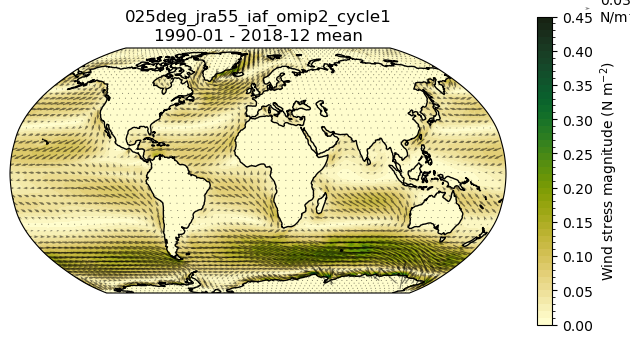

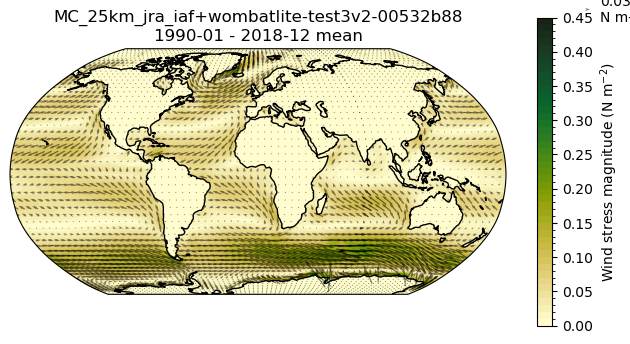

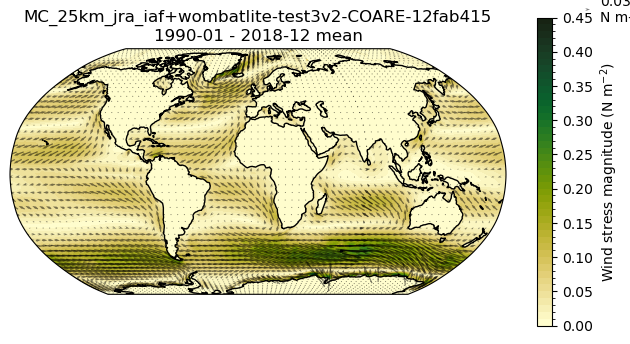

In [20]:
for expt in data_tm_interp["tauuo"]:
    print(expt)
    fig = plt.figure(figsize = (8,4))
    ax = plt.axes(projection=ccrs.Robinson())
    tauuo = data_tm_interp["tauuo"][expt]
    tauvo = data_tm_interp["tauvo"][expt]
    np.sqrt(tauuo**2 + tauvo**2).plot.contourf(
        ax=ax,
        transform=ccrs.PlateCarree(),
        cmap='cmo.speed',
        cbar_kwargs={'label':'Wind stress magnitude (N m$^{-2}$)'},
        levels=46,
        vmax=0.45)
    vectors = xr.merge([tauuo[::20,::20], tauvo[::20,::20]])
    vectors.plot.quiver(x='xq', y='yq', u='tauuo', v='tauvo', ax=ax,
                        transform=ccrs.PlateCarree(), alpha=0.5,
                        headwidth=2, headlength=3)
    ax.coastlines();
    plt.title(f"{expt}\n{data["tauuo"][expt].time.values[0].strftime('%Y-%m')} - {data["tauuo"][expt].time.values[-1].strftime('%Y-%m')} mean")

025deg_jra55_iaf_omip2_cycle1


/jobfs/170407689.gadi-pbs/ipykernel_1604715/1942848558.py:28: FutureWarning: In a future version of xarray the default value for compat will change from compat='no_conflicts' to compat='override'. This is likely to lead to different results when combining overlapping variables with the same name. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set compat explicitly.
  vectors = xr.merge([tauuo_diff[::20,::20], tauvo_diff[::20,::20]])
/jobfs/170407689.gadi-pbs/ipykernel_1604715/1942848558.py:28: FutureWarning: In a future version of xarray the default value for compat will change from compat='no_conflicts' to compat='override'. This is likely to lead to different results when combining overlapping variables with the same name. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set compat explicitly.
  vectors = xr.merge([tauuo_diff[::20,::20], tauvo_diff

MC_25km_jra_iaf+wombatlite-test3v2-COARE-12fab415


/jobfs/170407689.gadi-pbs/ipykernel_1604715/1942848558.py:28: FutureWarning: In a future version of xarray the default value for compat will change from compat='no_conflicts' to compat='override'. This is likely to lead to different results when combining overlapping variables with the same name. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set compat explicitly.
  vectors = xr.merge([tauuo_diff[::20,::20], tauvo_diff[::20,::20]])
/jobfs/170407689.gadi-pbs/ipykernel_1604715/1942848558.py:28: FutureWarning: In a future version of xarray the default value for compat will change from compat='no_conflicts' to compat='override'. This is likely to lead to different results when combining overlapping variables with the same name. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set compat explicitly.
  vectors = xr.merge([tauuo_diff[::20,::20], tauvo_diff

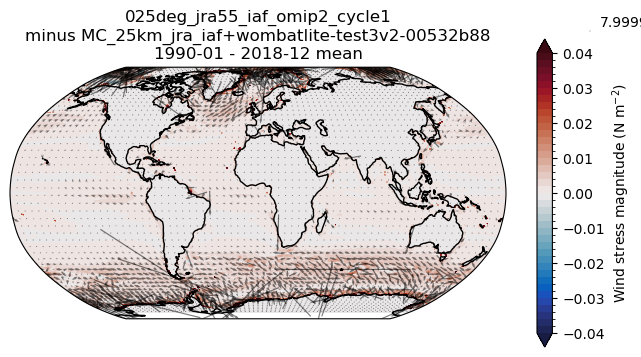

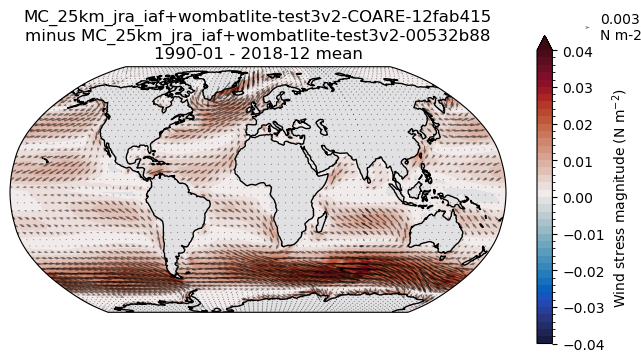

In [21]:
# plot difference from exptname
tauuo = data_tm_interp["tauuo"][exptname]
tauvo = data_tm_interp["tauvo"][exptname]
taumag_exptname = np.sqrt(tauuo**2 + tauvo**2)
for expt in data_tm_interp["tauuo"]:
    if expt != exptname: #not in [exptname, om2expt]:
        print(expt)
        fig = plt.figure(figsize = (8,4))
        ax = plt.axes(projection=ccrs.Robinson())
        tauuo = data_tm_interp["tauuo"][expt]
        tauvo = data_tm_interp["tauvo"][expt]
        if expt == om2expt:
            tauuo = tauuo.interp(yq=data_tm_interp["tauuo"][exptname].yq,
                                 xq=data_tm_interp["tauuo"][exptname].xq)
            tauvo = tauvo.interp(yq=data_tm_interp["tauvo"][exptname].yq,
                                 xq=data_tm_interp["tauvo"][exptname].xq)
        taumag_expt = np.sqrt(tauuo**2 + tauvo**2)
        tauuo_diff = tauuo - data_tm_interp["tauuo"][exptname]
        tauvo_diff = tauvo - data_tm_interp["tauvo"][exptname]
        (taumag_expt - taumag_exptname).plot.contourf(
            ax=ax,
            transform=ccrs.PlateCarree(),
            cmap='cmo.balance',
            cbar_kwargs={'label':'Wind stress magnitude (N m$^{-2}$)'},
            levels=41,
            vmax=0.04
        )
        vectors = xr.merge([tauuo_diff[::20,::20], tauvo_diff[::20,::20]])
        vectors.plot.quiver(x='xq', y='yq', u='tauuo', v='tauvo', ax=ax,
                            transform=ccrs.PlateCarree(), alpha=0.5,
                            headwidth=2, headlength=3)
        ax.coastlines();
        plt.title(f"{expt}\nminus {exptname}\n{data["tauuo"][expt].time.values[0].strftime('%Y-%m')} - {data["tauuo"][expt].time.values[-1].strftime('%Y-%m')} mean")

### Plot 2d histograms of stress

025deg_jra55_iaf_omip2_cycle1
MC_25km_jra_iaf+wombatlite-test3v2-COARE-12fab415


/g/data/xp65/public/apps/med_conda/envs/analysis3-26.03/lib/python3.12/site-packages/IPython/core/events.py:100: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  func(*args, **kwargs)


<Figure size 1000x400 with 0 Axes>

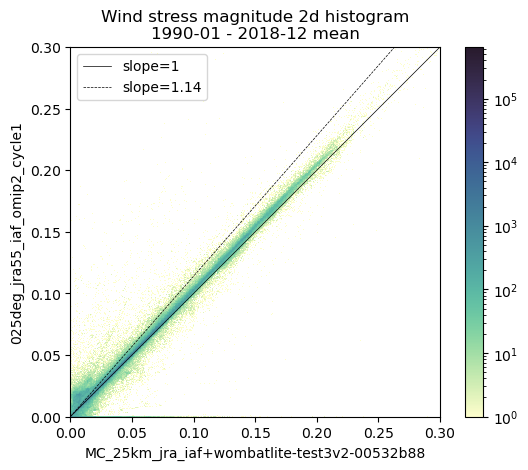

<Figure size 1000x400 with 0 Axes>

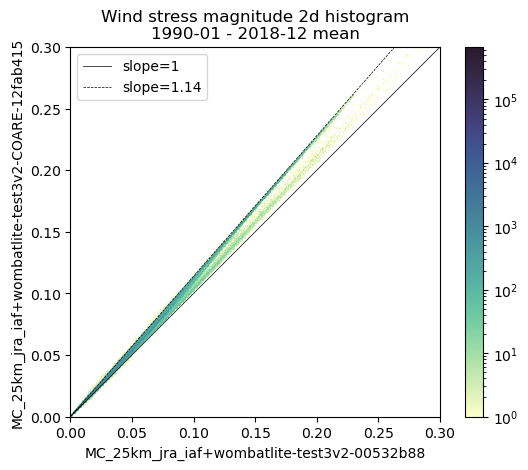

In [22]:
# plot 2d histograms of expt vs exptname
tauuo = data_tm_interp["tauuo"][exptname]
tauvo = data_tm_interp["tauvo"][exptname]
taumag_exptname = np.sqrt(tauuo**2 + tauvo**2)
for expt in data_tm_interp["tauuo"]:
    if expt != exptname:
        print(expt)
        plt.figure(figsize = (10,4))
        fig, ax = plt.subplots(1, 1)
        tauuo = data_tm_interp["tauuo"][expt]
        tauvo = data_tm_interp["tauvo"][expt]
        if expt == om2expt:
            tauuo = tauuo.interp(yq=data_tm_interp["tauuo"][exptname].yq,
                                 xq=data_tm_interp["tauuo"][exptname].xq)
            tauvo = tauvo.interp(yq=data_tm_interp["tauvo"][exptname].yq,
                                 xq=data_tm_interp["tauvo"][exptname].xq)
        taumag_expt = np.sqrt(tauuo**2 + tauvo**2)
        plt.hist2d(taumag_exptname.data.flatten(),
                   taumag_expt.data.flatten(),
                   range=[[0, 0.3], [0, 0.3]],
                   cmap='cmo.deep',
                   bins=500,
                   norm="log",
                    )
        for i, slope in enumerate([1, 1.14]):
            plt.plot(ax.get_xlim(), np.array(ax.get_ylim())*slope, color='black', linewidth=0.5, linestyle=['-', '--', ':'][i], label=f"slope={slope}")
        plt.legend()
        ax.set_aspect("equal")
        plt.xlabel(exptname)
        plt.ylabel(expt)
        plt.colorbar()
        plt.title(f"Wind stress magnitude 2d histogram\n{data["tauuo"][expt].time.values[0].strftime('%Y-%m')} - {data["tauuo"][expt].time.values[-1].strftime('%Y-%m')} mean")

025deg_jra55_iaf_omip2_cycle1
MC_25km_jra_iaf+wombatlite-test3v2-COARE-12fab415


/g/data/xp65/public/apps/med_conda/envs/analysis3-26.03/lib/python3.12/site-packages/IPython/core/events.py:100: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  func(*args, **kwargs)


<Figure size 1000x400 with 0 Axes>

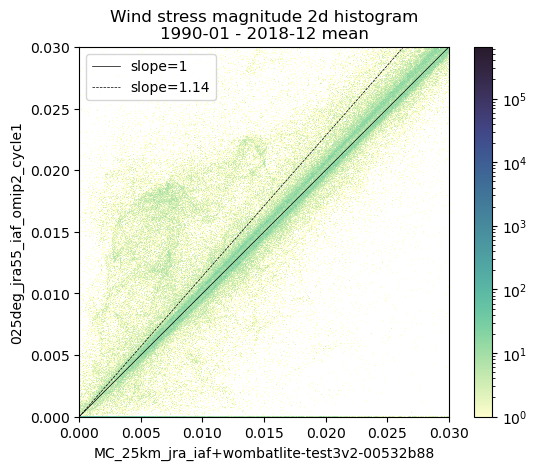

<Figure size 1000x400 with 0 Axes>

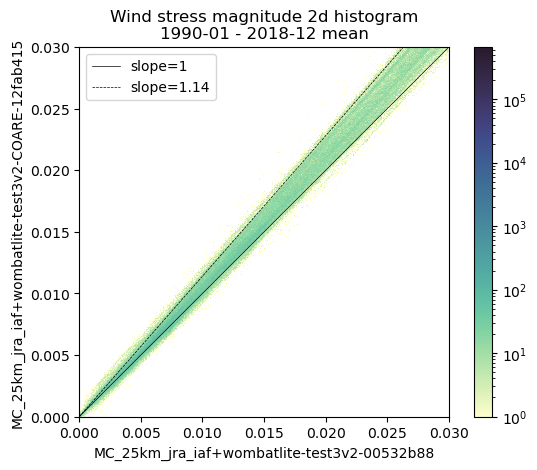

In [23]:
# plot 2d histograms of expt vs exptname (at low wind-stress end)
tauuo = data_tm_interp["tauuo"][exptname]
tauvo = data_tm_interp["tauvo"][exptname]
taumag_exptname = np.sqrt(tauuo**2 + tauvo**2)
for expt in data_tm_interp["tauuo"]:
    if expt != exptname:
        print(expt)
        plt.figure(figsize = (10,4))
        fig, ax = plt.subplots(1, 1)
        tauuo = data_tm_interp["tauuo"][expt]
        tauvo = data_tm_interp["tauvo"][expt]
        if expt == om2expt:
            tauuo = tauuo.interp(yq=data_tm_interp["tauuo"][exptname].yq,
                                 xq=data_tm_interp["tauuo"][exptname].xq)
            tauvo = tauvo.interp(yq=data_tm_interp["tauvo"][exptname].yq,
                                 xq=data_tm_interp["tauvo"][exptname].xq)
        taumag_expt = np.sqrt(tauuo**2 + tauvo**2)
        plt.hist2d(taumag_exptname.data.flatten(),
                   taumag_expt.data.flatten(),
                   range=[[0, 0.03], [0, 0.03]],
                   cmap='cmo.deep',
                   bins=500,
                   norm="log",
                    )
        for i, slope in enumerate([1, 1.14]):
            plt.plot(ax.get_xlim(), np.array(ax.get_ylim())*slope, color='black', linewidth=0.5, linestyle=['-', '--', ':'][i], label=f"slope={slope}")
        plt.legend()
        ax.set_aspect("equal")
        plt.xlabel(exptname)
        plt.ylabel(expt)
        plt.colorbar()
        plt.title(f"Wind stress magnitude 2d histogram\n{data["tauuo"][expt].time.values[0].strftime('%Y-%m')} - {data["tauuo"][expt].time.values[-1].strftime('%Y-%m')} mean")

### Calculate curl
Apply Stokes' theorem to the uninterpolated C-grid stresses to get the curl at the NE corner points from circulation per unit area around the corner cell, following https://xgcm.readthedocs.io/en/latest/xgcm-examples/02_mitgcm/?h=curl#vorticity

In [24]:
%%time
data_tm['curl'] = dict()
for expt in data_tm['tauuo'].keys():
    if expt != om2expt:
        print(expt)
        dx = grid.get_metric(data_tm['tauuo'][expt],'X')
        dy = grid.get_metric(data_tm['tauvo'][expt],'Y')
        circulation = (
            -grid.diff(data_tm['tauuo'][expt] * dx, 'Y')
            +grid.diff(data_tm['tauvo'][expt] * dy, 'X') 
        )
        data_tm['curl'][expt] = (
            circulation 
            / grid.get_metric(circulation, ['X', 'Y'])  # area
        ).compute()  # why doesn't this compute?

MC_25km_jra_iaf+wombatlite-test3v2-00532b88
MC_25km_jra_iaf+wombatlite-test3v2-COARE-12fab415
CPU times: user 301 ms, sys: 25.8 ms, total: 326 ms
Wall time: 300 ms


### Plot curl and curl difference
BUG: incorrect mapping in tripolar region (though values are ok)

MC_25km_jra_iaf+wombatlite-test3v2-00532b88
MC_25km_jra_iaf+wombatlite-test3v2-COARE-12fab415


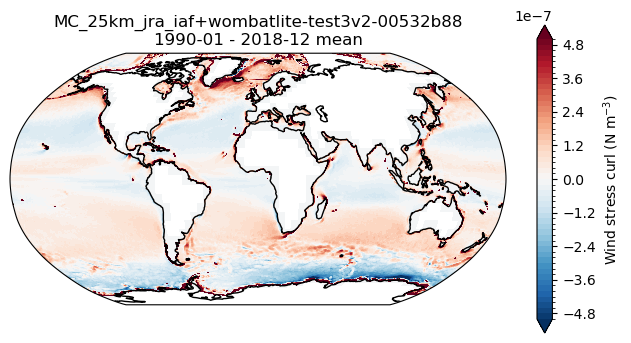

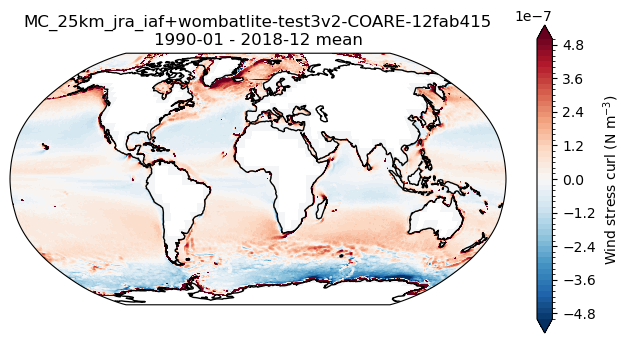

In [25]:
for expt, curl in data_tm["curl"].items():
    print(expt)
    fig = plt.figure(figsize = (8,4))
    ax = plt.axes(projection=ccrs.Robinson())
    curl.plot.contourf(
        ax=ax,
        transform=ccrs.PlateCarree(),
        cbar_kwargs={'label':'Wind stress curl (N m$^{-3}$)'},
        levels=51,
        vmax=0.5e-6)
    ax.coastlines();
    plt.title(f"{expt}\n{data["tauuo"][expt].time.values[0].strftime('%Y-%m')} - {data["tauuo"][expt].time.values[-1].strftime('%Y-%m')} mean")

MC_25km_jra_iaf+wombatlite-test3v2-COARE-12fab415


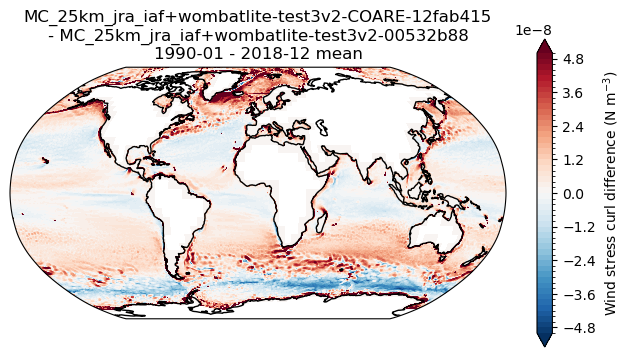

In [26]:
for expt, curl in data_tm["curl"].items():
    if expt != exptname:
        print(expt)
        fig = plt.figure(figsize = (8,4))
        ax = plt.axes(projection=ccrs.Robinson())
        (curl - data_tm["curl"][exptname]).plot.contourf(
            ax=ax,
            transform=ccrs.PlateCarree(),
            cbar_kwargs={'label':'Wind stress curl difference (N m$^{-3}$)'},
            levels=51,
            vmax=0.05e-6
        )
        ax.coastlines();
        plt.title(f"{expt}\n- {exptname}\n{data["tauuo"][expt].time.values[0].strftime('%Y-%m')} - {data["tauuo"][expt].time.values[-1].strftime('%Y-%m')} mean")

### Plot 2d histograms of curl

MC_25km_jra_iaf+wombatlite-test3v2-COARE-12fab415


/g/data/xp65/public/apps/med_conda/envs/analysis3-26.03/lib/python3.12/site-packages/IPython/core/events.py:100: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  func(*args, **kwargs)


<Figure size 1000x400 with 0 Axes>

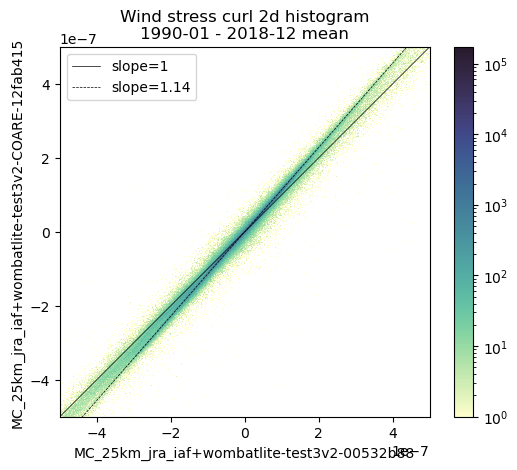

In [27]:
# plot 2d histograms of expt vs exptname curl
curl_exptname = data_tm["curl"][exptname]
for expt in data_tm["curl"]:
    if expt != exptname:
        print(expt)
        plt.figure(figsize = (10,4))
        fig, ax = plt.subplots(1, 1)
        curl_expt = data_tm["curl"][expt]
        plt.hist2d(curl_exptname.data.flatten(),
                   curl_expt.data.flatten(),
                   range=[[-5e-7, 5e-7], [-5e-7, 5e-7]],
                   cmap='cmo.deep',
                   bins=500,
                   norm="log",
                    )
        for i, slope in enumerate([1, 1.14]):
            plt.plot(ax.get_xlim(), np.array(ax.get_ylim())*slope, color='black', linewidth=0.5, linestyle=['-', '--', ':'][i], label=f"slope={slope}")
        plt.legend()
        ax.set_aspect("equal")
        plt.xlabel(exptname)
        plt.ylabel(expt)
        plt.colorbar()
        plt.title(f"Wind stress curl 2d histogram\n{data["tauuo"][expt].time.values[0].strftime('%Y-%m')} - {data["tauuo"][expt].time.values[-1].strftime('%Y-%m')} mean")